# Лабораторна робота 2 — Проста лінійна регресія (аналітичний розв'язок)


**Набір даних:** `kc_house_data.csv`  
**Обмеження:** scikit-learn-регресія **не дозволена** для базових завдань.

## Налаштування

In [ ]:
import sys
!{sys.executable} -m pip install numpy pandas matplotlib --quiet


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

%matplotlib inline


## Теоретичне підґрунтя

Для однієї вхідної ознаки **x** та виходу **y** аналітичний розв'язок МНК:
```
slope     = ( Σ(xᵢ·yᵢ) − n·x̄·ȳ )  /  ( Σ(xᵢ²) − n·x̄² )
intercept = ȳ − slope · x̄
```
Сума квадратів залишків (RSS):
```
RSS = Σ ( yᵢ − (intercept + slope·xᵢ) )²
```

---
## Завдання 1 — Підготовка даних

Завантажте `kc_house_data.csv`. Розбийте на **навчальну (20 %) та тестову (80 %)** вибірки з `random_state=0`.

In [ ]:
sales = pd.read_csv('kc_house_data.csv')
train_data, test_data = train_test_split(sales, test_size=0.8, random_state=0)
print(f'Навчальна: {len(train_data)} рядків  |  Тестова: {len(test_data)} рядків')


Навчальна: 4322 рядків  |  Тестова: 17291 рядків


---
## Завдання 2 — Реалізація `simple_linear_regression()`

Завершіть функцію, використовуючи **лише NumPy** (без sklearn, без циклів по рядках).

In [ ]:
def simple_linear_regression(input_feature, output):
    """
    Обчислює slope та intercept МНК для однієї ознаки.

    Параметри
    ----------
    input_feature : array-like, shape (n,)
    output        : array-like, shape (n,)

    Повертає
    -------
    intercept, slope : float, float
    """
    input_feature = np.array(input_feature, dtype=float)
    output        = np.array(output, dtype=float)
    n = len(input_feature)

    # Compute slope
    x_mean = np.mean(input_feature)
    y_mean = np.mean(output)

    slope = (
        np.sum(input_feature * output) - n * x_mean * y_mean
    ) / (
        np.sum(input_feature ** 2) - n * x_mean ** 2
    )

    # Compute intercept
    intercept = y_mean - slope * x_mean

    return intercept, slope


### Перевірка — обидва значення нижче мають дорівнювати **1.0**

In [ ]:
test_feature = np.arange(5, dtype=float)
test_output  = 1.0 + 1.0 * test_feature
test_intercept, test_slope = simple_linear_regression(test_feature, test_output)
print(f'Intercept: {test_intercept:.4f}  (очікується 1.0)')
print(f'Slope    : {test_slope:.4f}  (очікується 1.0)')


Intercept: 1.0000  (очікується 1.0)
Slope    : 1.0000  (очікується 1.0)


### Навчання на `sqft_living`

In [ ]:
sqft_intercept, sqft_slope = simple_linear_regression(
    train_data['sqft_living'], train_data['price']
)
print(f'Вільний член: {sqft_intercept:.2f}')
print(f'Нахил: {sqft_slope:.4f}')


Вільний член: -29748.29
Нахил: 273.5299


---
## Завдання 3 — Передбачення та RSS

**а)** Реалізуйте `get_regression_predictions(input_feature, intercept, slope)` — повертає масив NumPy передбачених значень.  
**б)** Реалізуйте `get_residual_sum_of_squares(input_feature, output, intercept, slope)` — обчислює RSS.  
**в)** Перевірте обидві функції, потім вкажіть RSS на навчальній і тестовій вибірках та дайте відповідь на питання нижче.

In [ ]:
def get_regression_predictions(input_feature, intercept, slope):
    """Повертає масив передбачених значень."""

    input_feature = np.array(input_feature, dtype=float)

    predictions = intercept + slope * input_feature

    return predictions

In [ ]:
def get_residual_sum_of_squares(input_feature, output, intercept, slope):
    """Повертає RSS (скаляр)."""

    predictions = get_regression_predictions(
        input_feature, intercept, slope
    )

    rss = np.sum((output - predictions) ** 2)

    return rss

### Перевірка — RSS на тестових вхідних даних має бути **0.0**

In [ ]:
rss_check = get_residual_sum_of_squares(
    test_feature, test_output, test_intercept, test_slope
)
print(f'RSS на тестових вхідних даних: {rss_check:.2f}  (очікується 0.0)')


RSS на тестових вхідних даних: 0.00  (очікується 0.0)


### RSS для моделі `sqft_living`

In [ ]:
rss_train = get_residual_sum_of_squares(
    train_data['sqft_living'], train_data['price'],
    sqft_intercept, sqft_slope
)
rss_test = get_residual_sum_of_squares(
    test_data['sqft_living'], test_data['price'],
    sqft_intercept, sqft_slope
)
print(f'Навчальна RSS: {rss_train:.2e}')
print(f'Тестова  RSS: {rss_test:.2e}')


Навчальна RSS: 2.74e+14
Тестова  RSS: 1.20e+15


### Питання — яка передбачувана ціна будинку площею 2 650 кв. футів?

In [ ]:
my_house_sqft = 2650
# Завдання 3в — обчисліть і виведіть передбачувану ціну

predicted_price = get_regression_predictions(
    my_house_sqft,
    sqft_intercept,
    sqft_slope
)

print(f'Передбачувана ціна: {predicted_price:.2f}')

Передбачувана ціна: 695105.98


---
## Завдання 4 — Порівняння двох ознак

Навчіть другу модель, використовуючи `bedrooms` як вхідну ознаку. Обчисліть RSS на **тестовій вибірці** для обох моделей (`sqft_living` і `bedrooms`). Яка ознака дає кращий прогноз? Поясніть у 2–3 реченнях.

In [ ]:
# Навчіть модель на ознаці bedrooms
bedrooms_intercept, bedrooms_slope = simple_linear_regression(
    train_data['bedrooms'],
    train_data['price']
)

# Обчисліть тестову RSS для обох моделей

rss_sqft = get_residual_sum_of_squares(
    test_data['sqft_living'],
    test_data['price'],
    sqft_intercept,
    sqft_slope
)

rss_bedrooms = get_residual_sum_of_squares(
    test_data['bedrooms'],
    test_data['price'],
    bedrooms_intercept,
    bedrooms_slope
)

print(f'Тестова RSS (sqft_living): {rss_sqft:.2e}')
print(f'Тестова RSS (bedrooms): {rss_bedrooms:.2e}')

Тестова RSS (sqft_living): 1.20e+15
Тестова RSS (bedrooms): 2.15e+15


**Відповідь:** *Ознака sqft_living дає кращий прогноз вартості будинку, оскільки її тестова RSS (1.20·10¹⁵) є меншою за RSS моделі на основі bedrooms (2.15·10¹⁵). Це свідчить про те, що житлова площа сильніше пов'язана з ціною будинку, ніж кількість спалень. Тому модель з ознакою sqft_living забезпечує точніші прогнози.

---
## ✨ Бонус — Зворотна регресія

Реалізуйте `inverse_regression_predictions(output, intercept, slope)`, яка розв'язує рівняння регресії у зворотному напрямку: за цільовою ціною оцінює необхідну площу `sqft_living`. Побудуйте пряму регресії на діаграмі розсіювання навчальних даних і позначте точку ($800 000, ваша відповідь) на графіку.

In [ ]:
def inverse_regression_predictions(output, intercept, slope):
    """Повертає оцінку input_feature для заданого output."""

    output = np.array(output, dtype=float)

    return (output - intercept) / slope


Оцінена площа для будинку вартістю $800000: 3033.48 кв. футів


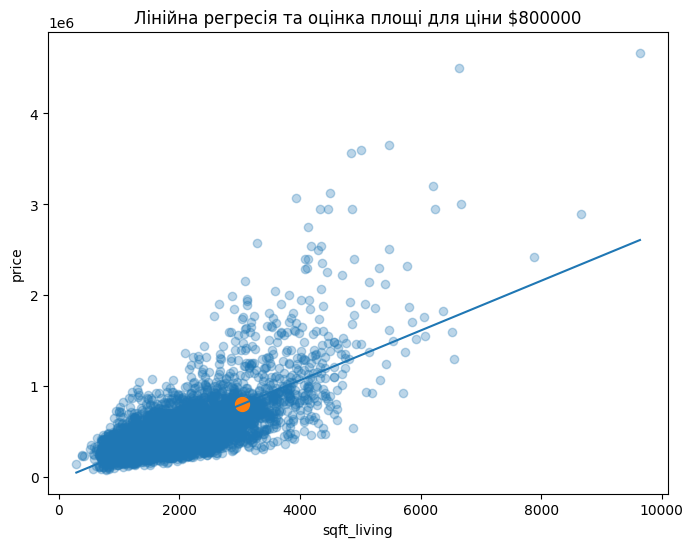

In [ ]:
# Бонус — оцініть площу для будинку вартістю $800 000 та побудуйте графік
target_price = 800000

estimated_sqft = inverse_regression_predictions(
    target_price,
    sqft_intercept,
    sqft_slope
)

print(f'Оцінена площа для будинку вартістю $800000: {estimated_sqft:.2f} кв. футів')


# Побудова графіка

plt.figure(figsize=(8, 6))

plt.scatter(
    train_data['sqft_living'],
    train_data['price'],
    alpha=0.3
)

x = np.array([
    train_data['sqft_living'].min(),
    train_data['sqft_living'].max()
])

y = sqft_intercept + sqft_slope * x

plt.plot(x, y)

plt.scatter(
    estimated_sqft,
    target_price,
    s=100
)

plt.xlabel('sqft_living')
plt.ylabel('price')
plt.title('Лінійна регресія та оцінка площі для ціни $800000')

plt.show()